# RoadGuard
#### A pothole detection system

This notebook will walk through the development of our ML classification model that identifies potholes on roads.

## Setup

Import required packages:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Preprocessing

In [4]:
temp_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224), #final input dimension
    transforms.ToTensor()
])

temp_dataset = datasets.ImageFolder('./data', transform=temp_transform)
temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False, num_workers=0)

In [5]:
def calculate_mean(loader):
    channel_sum = torch.zeros(3)
    channel_count = 0

    for images, _ in loader:
        channel_sum += torch.mean(images, dim=[0, 2, 3]) * images.shape[0] #means of RGB channels per batch
        channel_count += images.shape[0] # of imgs in batch
        
    # Final Mean (sum of means * number of samples / total number of samples)
    mean = channel_sum / channel_count
    return mean.tolist()

def calculate_std(mean, loader):
    mean_tensor = torch.tensor(mean).view(1, 3, 1, 1)
    
    # Initialize running sum of squared differences
    channel_std_sum = torch.zeros(3)
    channel_count = 0
    
    for images, _ in loader:
        # Calculate the difference squared: (Image - Mean)^2
        # This uses broadcasting: (B, 3, H, W) - (1, 3, 1, 1)
        diff = (images - mean_tensor).pow(2)
        
        # Sum the squared differences across H, W, and B (Batch)
        channel_std_sum += torch.sum(diff, dim=[0, 2, 3])
        channel_count += diff.shape[0] * diff.shape[2] * diff.shape[3]
        
    # The final Standard Deviation is the square root of the average squared difference (Variance)
    # We use (N - 1) for the denominator for sample standard deviation, but N (total pixels) 
    # is often used for large datasets to simplify.
    std = torch.sqrt(channel_std_sum / channel_count) 
    return std.tolist()

In [6]:
# Calculate mean and std from your dataset
dataset_mean = calculate_mean(temp_loader)
dataset_std = calculate_std(dataset_mean, temp_loader)

print(f"Dataset Mean: {dataset_mean}")
print(f"Dataset Std: {dataset_std}")

# Create the final transform WITH standardization
final_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)  # This actually standardizes
])

# Create final dataset with standardization
dataset = datasets.ImageFolder('./data', transform=final_transform)

# Split into train/val/test
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"\nTrain: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataset Mean: [0.4876047968864441, 0.4831056296825409, 0.4614783823490143]
Dataset Std: [0.2261897623538971, 0.22046837210655212, 0.23990650475025177]

Train: 476, Val: 102, Test: 103


Now we can build the model architecture.

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # One convolutional layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        
        # One fully connected layer
        # After conv and pool: 224 -> 112, so 112*112*16 input features
        self.fc1 = nn.Linear(112 * 112 * 16, 2)  # 2 classes: normal/pothole
        
    def forward(self, x):
        # Convolutional layer with ReLU and pooling
        x = self.conv1(x)
        x = self.pool(x)
        x = self.relu(x)
        
        # Flatten for fully connected layer
        x = x.view(x.size(0), -1)
        
        # Fully connected layer
        x = self.fc1(x)
        
        return x

This architecture can serve as the baseline model for this problem. Let's train this model and see how well it does.

In [8]:
# Create model instance
model = CNN().to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define number of epochs
NUM_EPOCHS = 10

# Lists to track losses
train_losses = []
val_losses = []

# Helper function to compute correct labels
def compute_correct_labels(outputs, labels):
    _, predicted_values = torch.max(outputs, 1)
    correct = (predicted_values == labels).sum().item()
    total = labels.size(0)
    return correct, total

# Training loop
for epoch in range(NUM_EPOCHS):
    
    # Training phase
    model.train()
    total_train_loss = 0.0
    total_train_correct = 0
    total_train_images = 0
    
    for train_inputs, train_labels in train_loader:
        train_inputs, train_labels = train_inputs.to(device), train_labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(train_inputs)
        
        # Compute stats
        train_correct, train_total = compute_correct_labels(outputs, train_labels)
        total_train_correct += train_correct
        total_train_images += train_total
        
        # Backward pass
        loss = criterion(outputs, train_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    model.eval()
    total_val_loss = 0.0
    total_val_correct = 0
    total_val_images = 0
    
    with torch.no_grad():
        for val_inputs, val_labels in val_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            
            # Forward pass
            outputs = model(val_inputs)
            
            # Compute stats
            val_correct, val_total = compute_correct_labels(outputs, val_labels)
            total_val_correct += val_correct
            total_val_images += val_total
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f}, Train Correct: {total_train_correct}/{total_train_images} - " \
          f"Val Loss: {avg_val_loss:.4f}, " \
          f"Val Correct: {total_val_correct}/{total_val_images}")


Epoch 1/10 - Train Loss: 6.7358, Train Correct: 320/476 - Val Loss: 2.6242, Val Correct: 77/102
Epoch 2/10 - Train Loss: 1.5864, Train Correct: 398/476 - Val Loss: 0.6413, Val Correct: 87/102
Epoch 3/10 - Train Loss: 0.4186, Train Correct: 430/476 - Val Loss: 0.7818, Val Correct: 87/102
Epoch 4/10 - Train Loss: 0.1164, Train Correct: 463/476 - Val Loss: 0.6307, Val Correct: 87/102
Epoch 5/10 - Train Loss: 0.0175, Train Correct: 473/476 - Val Loss: 0.3664, Val Correct: 92/102
Epoch 6/10 - Train Loss: 0.0108, Train Correct: 474/476 - Val Loss: 0.3302, Val Correct: 92/102
Epoch 7/10 - Train Loss: 0.0106, Train Correct: 474/476 - Val Loss: 0.3414, Val Correct: 91/102
Epoch 8/10 - Train Loss: 0.0019, Train Correct: 476/476 - Val Loss: 0.3621, Val Correct: 92/102
Epoch 9/10 - Train Loss: 0.0011, Train Correct: 476/476 - Val Loss: 0.3256, Val Correct: 92/102
Epoch 10/10 - Train Loss: 0.0007, Train Correct: 476/476 - Val Loss: 0.3328, Val Correct: 92/102


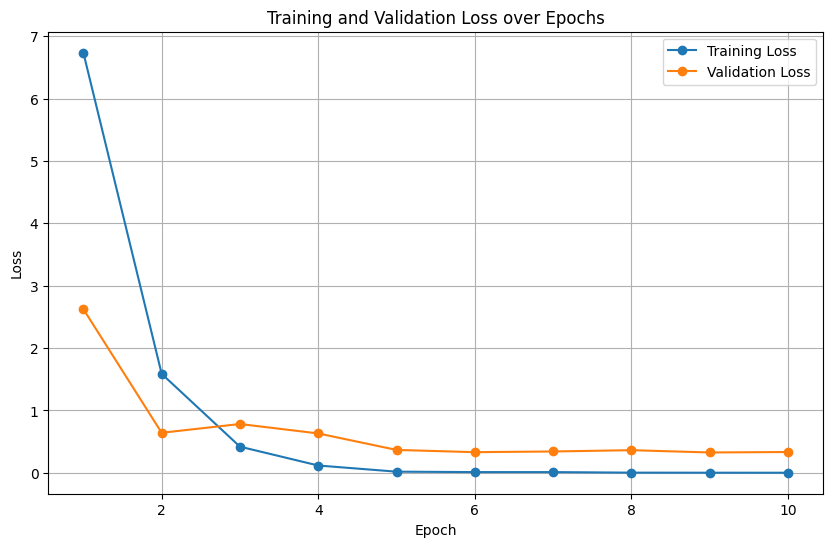

In [9]:
# Plot training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

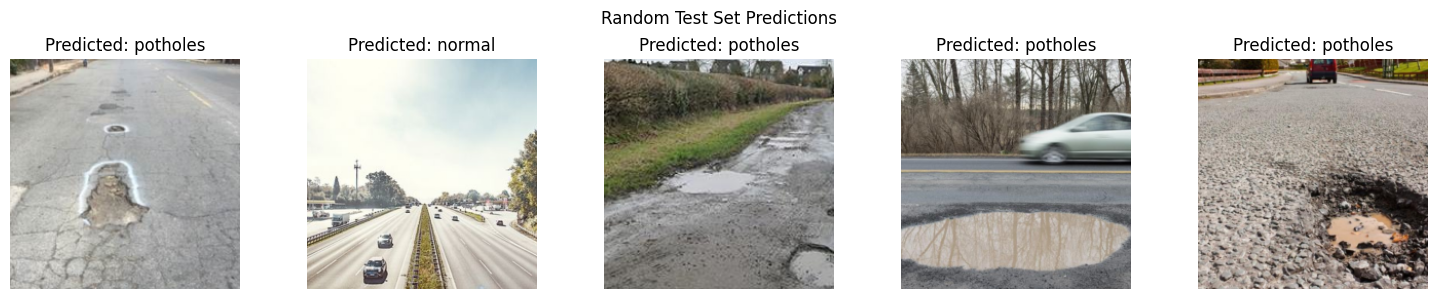

In [10]:
# Set model to evaluation mode
model.eval()

# Get class names
class_names = dataset.classes  # ['normal', 'potholes']

# Randomly select 5 images from test set
test_indices = np.random.choice(len(test_dataset), size=5, replace=False)

# Create figure
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for idx, test_idx in enumerate(test_indices):
    # Get image and true label
    image_tensor, true_label = test_dataset[test_idx]
    
    # Get the original image for display (denormalize)
    img_display = image_tensor.clone()
    for t, m, s in zip(img_display, dataset_mean, dataset_std):
        t.mul_(s).add_(m)
    img_display = img_display.permute(1, 2, 0).cpu().numpy()
    img_display = np.clip(img_display, 0, 1)
    
    # Make prediction
    input_tensor = image_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = torch.max(output, 1)
    
    predicted_class = class_names[predicted.item()]
    
    # Plot
    axes[idx].imshow(img_display)
    axes[idx].axis('off')
    axes[idx].set_title(f'Predicted: {predicted_class}')

plt.suptitle('Random Test Set Predictions')
plt.tight_layout()
plt.show()


It isn't perfect (the fourth image is wrongly classified) but we're doing good.

Let's check the final model performance on an unseen test set, using various metrics and a confusion matrix

In [18]:
from sklearn.metrics import confusion_matrix

# Assuming device, model, and test_loader are defined

model.eval() 
all_labels = []    # List to store all true labels
all_predicted = [] # List to store all predicted labels

with torch.no_grad():
    for test_inputs, test_labels in test_loader:
        
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
        
        outputs = model(test_inputs)
        _, predicted_values = torch.max(outputs, 1)
        
        # Append to lists (move back to CPU for numpy/sklearn)
        all_labels.extend(test_labels.cpu().numpy())
        all_predicted.extend(predicted_values.cpu().numpy())

# Convert lists to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_predicted)

# Calculate the Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

In [19]:
TN = conf_matrix[0, 0]
FP = conf_matrix[0, 1]
FN = conf_matrix[1, 0]
TP = conf_matrix[1, 1]

# Calculate Precision
# Check for division by zero
if (TP + FP) > 0:
    precision = TP / (TP + FP)
else:
    precision = 0.0

# Calculate Recall
# Check for division by zero
if (TP + FN) > 0:
    recall = TP / (TP + FN)
else:
    recall = 0.0

#Calculate Accuracy
total_predictions = TP + TN + FP + FN
total_correct = TP + TN
# Check for division by zero before calculation
if total_predictions > 0:
    accuracy = total_correct / total_predictions
else:
    accuracy = 0.0

# Assuming precision and recall are calculated and non-zero
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN): {TN}")
print("-" * 30)
print(f"Precision (Pothole): {precision:.4f}")
print(f"Recall (Pothole):    {recall:.4f}")
print(f"Accuracy Score (from matrix): {accuracy:.4f}")
print(f"F1-Score (Pothole):  {f1_score:.4f}")


True Positives (TP): 50
False Positives (FP): 8
False Negatives (FN): 4
True Negatives (TN): 41
------------------------------
Precision (Pothole): 0.8621
Recall (Pothole):    0.9259
Accuracy Score (from matrix): 0.8835
F1-Score (Pothole):  0.8929


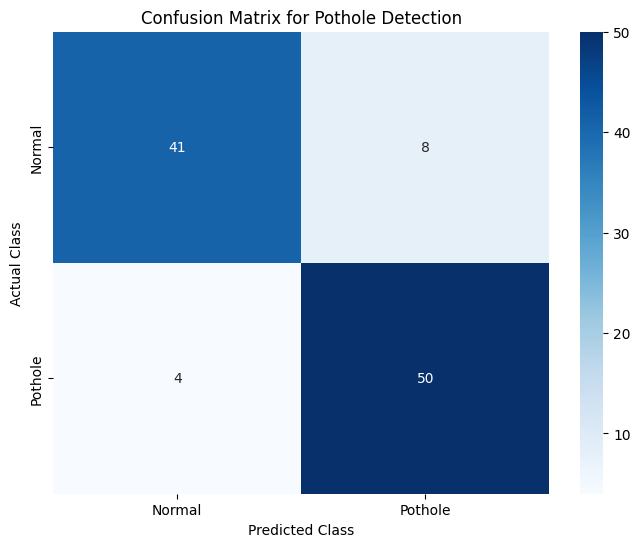

In [17]:
import seaborn as sns # Optional, but often used for prettier heatmaps

# Define class names (for labels on the plot)
class_names = ['Normal', 'Pothole']

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True,              # Annotate cells with the numeric value
    fmt='d',                 # Format annotations as integers
    cmap='Blues',            # Color scheme
    xticklabels=class_names, # Labels for predicted classes (X-axis)
    yticklabels=class_names  # Labels for actual classes (Y-axis)
)

# Set labels and title
plt.title('Confusion Matrix for Pothole Detection')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()